In [ ]:
# Implementation for Hope Speech Detection Shared Task – Task 1
# ==============================
# Task 1 – Run 1
# Model: Logistic Regression
# Feature: TF-IDF (max_features=5000)
# ==============================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report


In [ ]:
# Load shared task dataset files
train_df = pd.read_csv("/content/drive/MyDrive/Task1/train.csv")
dev_df = pd.read_csv("/content/drive/MyDrive/Task1/dev.csv")
test_df = pd.read_csv("/content/drive/MyDrive/Task1/test_data_withoutlabelCG.csv")


In [ ]:
print(train_df.columns)
print(dev_df.columns)


Index(['Text', 'Label'], dtype='object')
Index(['Text', 'Label'], dtype='object')


In [ ]:
X_train = train_df["Text"]
y_train = train_df["Label"]

X_dev = dev_df["Text"]
y_dev = dev_df["Label"]

X_test = test_df["Text"]


In [ ]:
vectorizer = TfidfVectorizer(max_features=5000)

X_train_vec = vectorizer.fit_transform(X_train)
X_dev_vec = vectorizer.transform(X_dev)
X_test_vec = vectorizer.transform(X_test)


In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)


LogisticRegression(max_iter=1000)

In [ ]:
dev_pred = model.predict(X_dev_vec)

print(classification_report(y_dev, dev_pred))


                   precision    recall  f1-score   support

     blended hope       0.46      0.17      0.25       191
discouraging hope       0.62      0.20      0.31       153
 encouraging hope       0.73      0.77      0.75       406
       uninvolved       0.65      0.90      0.75       534

         accuracy                           0.67      1284
        macro avg       0.62      0.51      0.52      1284
     weighted avg       0.64      0.67      0.62      1284



In [ ]:
test_pred = model.predict(X_test_vec)


In [ ]:
submission = pd.DataFrame({"labels": test_pred})

submission.to_csv("SJM_MINDS_Tulu_run1.csv", index=False)


In [ ]:
from google.colab import files
files.download("SJM_MINDS_Tulu_run1.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ==============================
# Task 1 – Run 2
# Model: LinearSVC
# Feature: TF-IDF (Unigram + Bigram)
# Text preprocessing applied
# ==============================
import pandas as pd
import re

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report


In [ ]:
# Load shared task dataset files
train_df = pd.read_csv("/content/drive/MyDrive/Task1/train.csv")
dev_df = pd.read_csv("/content/drive/MyDrive/Task1/dev.csv")
test_df = pd.read_csv("/content/drive/MyDrive/Task1/test_data_withoutlabelCG.csv")


In [ ]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#\w+", "", text)
    text = re.sub(r"[^\w\s]", "", text)
    return text


In [ ]:
train_df["clean_text"] = train_df["Text"].apply(clean_text)
dev_df["clean_text"] = dev_df["Text"].apply(clean_text)
test_df["clean_text"] = test_df["Text"].apply(clean_text)


In [ ]:
X_train = train_df["clean_text"]
y_train = train_df["Label"]

X_dev = dev_df["clean_text"]
y_dev = dev_df["Label"]

X_test = test_df["clean_text"]


In [ ]:
vectorizer = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1,2),   # unigram + bigram
    min_df=2
)


In [ ]:
X_train_vec = vectorizer.fit_transform(X_train)
X_dev_vec = vectorizer.transform(X_dev)
X_test_vec = vectorizer.transform(X_test)


In [ ]:
model = LinearSVC(class_weight="balanced")
model.fit(X_train_vec, y_train)


LinearSVC(class_weight='balanced')

In [ ]:
dev_pred = model.predict(X_dev_vec)
print(classification_report(y_dev, dev_pred))


                   precision    recall  f1-score   support

     blended hope       0.32      0.30      0.31       191
discouraging hope       0.33      0.34      0.34       153
 encouraging hope       0.75      0.72      0.73       406
       uninvolved       0.71      0.74      0.73       534

         accuracy                           0.62      1284
        macro avg       0.53      0.53      0.53      1284
     weighted avg       0.62      0.62      0.62      1284



In [ ]:
test_pred = model.predict(X_test_vec)


In [ ]:

submission = pd.DataFrame({"labels": test_pred})

submission.to_csv("SJM_MINDS_Tulu_run2.csv", index=False)


In [ ]:
from google.colab import files
files.download("SJM_MINDS_Tulu_run2.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Count the number of occurrences of each label in the Train dataset
import pandas as pd

# Load dataset
df = pd.read_csv("/content/drive/MyDrive/Task1/train.csv")


# Count labels
label_counts = df['Label'].value_counts()

print(label_counts)

Label
uninvolved           2490
encouraging hope     1895
blended hope          895
discouraging hope     711
Name: count, dtype: int64


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Count the number of occurrences of each label in the Development dataset

import pandas as pd


df = pd.read_csv("/content/drive/MyDrive/Task1/dev.csv")



label_counts = df['Label'].value_counts()

print(label_counts)

Label
uninvolved           534
encouraging hope     406
blended hope         191
discouraging hope    153
Name: count, dtype: int64


In [ ]:
# Count the number of occurrences of each label in the Test dataset
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Task1/test_data.csv")


label_counts = df['Label'].value_counts()

print(label_counts)

Label
encouraging hope     407
uninvolved           398
blended hope         172
discouraging hope    149
Name: count, dtype: int64


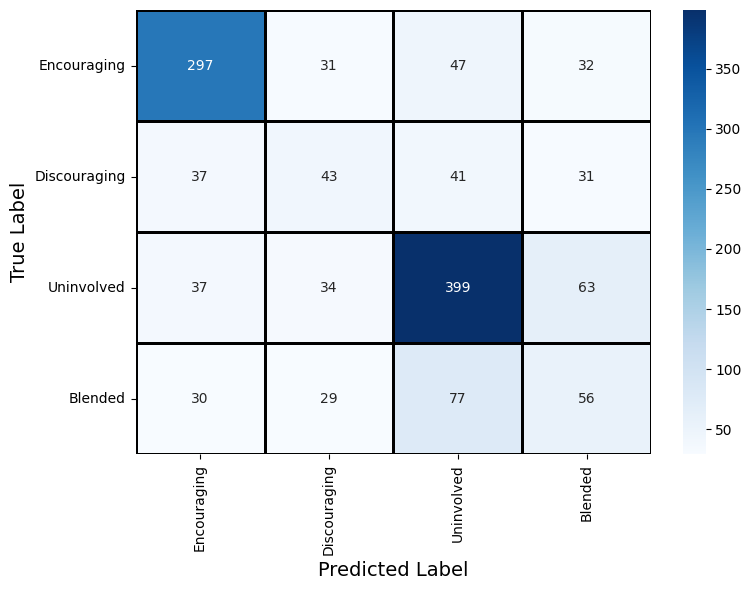

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#Code for generating Confusion Matrix for Task 1
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

true = pd.read_csv("/content/drive/MyDrive/test_CG_label.csv")
pred = pd.read_csv("/content/drive/MyDrive/Task1/SJM_MINDS_Tulu_run2.csv")

y_true = true["Label"]
y_pred = pred["labels"]

labels = ["encouraging hope","discouraging hope","uninvolved","blended hope"]

cm = confusion_matrix(y_true, y_pred, labels=labels)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Encouraging","Discouraging","Uninvolved","Blended"],
    yticklabels=["Encouraging","Discouraging","Uninvolved","Blended"],
    linewidths=1,
    linecolor="black"
)


#plt.title("Confusion Matrix for Task 1")
plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("True Label", fontsize=14)

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig("task1_confusion_matrix.png", dpi=400)
plt.show()
from google.colab import files
files.download("task1_confusion_matrix.png")

In [ ]:
#Error Analysis:Identifying Misclassifiaction samples
y_pred_task1 = model.predict(X_test_vec)

In [ ]:


test_data = pd.read_csv("/content/drive/MyDrive/test_CG_label.csv")

In [ ]:
print(test_data.columns)

Index(['ID', 'Text', 'Label'], dtype='object')


In [ ]:
pred = pd.read_csv("/content/SJM_MINDS_Tulu_run2.csv")

In [ ]:
error_df = pd.DataFrame({
    "Text": test_data["Text"],
    "Actual": test_data["Label"],
    "Predicted": y_pred_task1
})

In [ ]:
errors = error_df[error_df["Actual"] != error_df["Predicted"]]

print("Total Errors:", len(errors))

errors.head(40)

Total Errors: 489


,Text,Actual,Predicted
0,"Video masth edde aathnd, but starting d avvu k...",encouraging hope,blended hope
1,Imbye boka itte urchve encha marre!!?,discouraging hope,blended hope
5,Super please full nataka padle,discouraging hope,encouraging hope
6,Daily e serial update korle.....,uninvolved,discouraging hope
11,Maja talkies d chikkanna boka kuri same shit m...,uninvolved,encouraging hope
12,ini pura picture baruva,blended hope,uninvolved
14,Andu laxmish saree miss andu,blended hope,encouraging hope
19,"Aa Pacche Pacche Pajiru, Aa Selli Selli Neeru",uninvolved,blended hope
30,Thune maari entry yaar....yaan boordh thelthe ...,discouraging hope,uninvolved
32,ereg yenna thumbu hrudayad solmelu.,blended hope,encouraging hope


In [ ]:
errors.to_csv("error_analysis_task1.csv", index=False,encoding="utf-8-sig")
from google.colab import files
files.download("error_analysis_task1.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>